# Zain KSA (Tadawul: 7030) Stock Analysis
**16 years of daily price data (2010–2026) — technical analysis & corporate event impact**

Zain KSA (Mobile Telecommunications Company Saudi Arabia) is one of three major mobile
operators on the Saudi Stock Exchange (Tadawul), alongside STC and Mobily. This notebook
analyzes ~16 years of daily OHLCV data to answer:

**How did Zain KSA's two major capital restructurings — in 2012 and 2020 — affect its
price behavior and volatility, and what do standard technical indicators show about the
stock today?**

**Data:** 3,910 daily records (Mar 2010 – Jan 2026), sourced from Kaggle / Yahoo Finance (7030.SR).


## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv("data/zain_with_indicators.csv", parse_dates=["Date"])
df.head()

,Date,Close,High,Low,Open,Volume,zero_volume_day,daily_return,rolling_volatility_30d,SMA_20,SMA_50,SMA_200,RSI_14,MACD,MACD_signal,MACD_hist,BB_mid,BB_upper,BB_lower
0,2010-03-04,12.143493,12.143493,12.081851,12.081851,1833613,False,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
1,2010-03-07,12.143493,12.205135,12.081851,12.143493,2883045,False,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
2,2010-03-08,12.143493,12.143493,12.081851,12.143493,1786721,False,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
3,2010-03-09,12.020208,12.143492,12.020208,12.081851,1571287,False,-0.010152,NaN,NaN,NaN,NaN,NaN,-0.009835,-0.001967,-0.007868,NaN,NaN,NaN
4,2010-03-10,12.081851,12.143493,12.020209,12.020209,1610631,False,0.005128,NaN,NaN,NaN,NaN,NaN,-0.012510,-0.004076,-0.008435,NaN,NaN,NaN


## 2. Data Quality Check

The dataset has no missing values. About 5.4% of trading days show zero volume — this is
common for smaller-cap Tadawul stocks with lower liquidity, not a data error, so these
rows are flagged rather than dropped.

In [2]:
print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Missing values:\n{df.isna().sum()}")
print(f"Zero-volume days: {df['zero_volume_day'].sum()} ({df['zero_volume_day'].mean():.1%})")

Rows: 3910
Date range: 2010-03-04 to 2026-01-29
Missing values:
Date                        0
Close                       0
High                        0
Low                         0
Open                        0
Volume                      0
zero_volume_day             0
daily_return                1
rolling_volatility_30d     30
SMA_20                     19
SMA_50                     49
SMA_200                   199
RSI_14                     14
MACD                        0
MACD_signal                 0
MACD_hist                   0
BB_mid                     19
BB_upper                   19
BB_lower                   19
dtype: int64
Zero-volume days: 213 (5.4%)


## 3. Corporate Events

Two major capital restructurings are documented for Zain KSA:
- **2012:** Capital reduced from SAR 14B to SAR 4.8B
- **2020:** Capital reduced from SAR 5.837B to SAR 4.487B, followed by a SAR 4.5B rights issue

We mark these on the price chart to see how the stock behaved around each event.

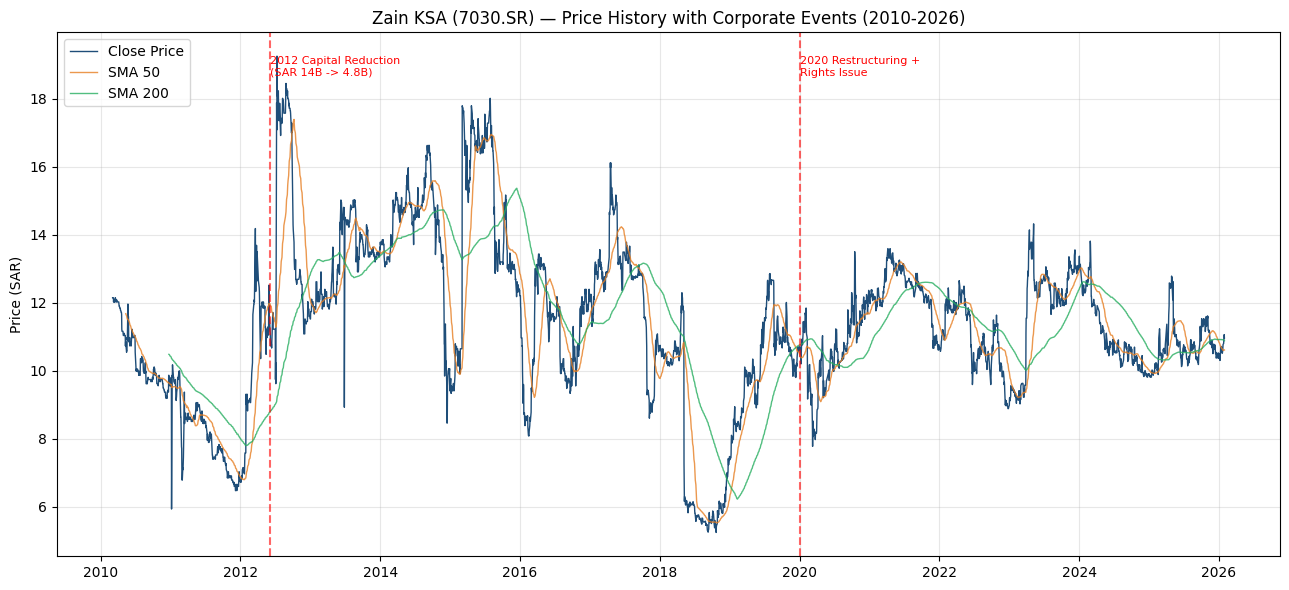

In [3]:
events = {
    "2012 Capital Reduction\n(SAR 14B -> 4.8B)": "2012-06-01",
    "2020 Restructuring +\nRights Issue": "2020-01-01",
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df["Date"], df["Close"], label="Close Price", color="#1f4e79", linewidth=1)
ax.plot(df["Date"], df["SMA_50"], label="SMA 50", color="#e67e22", linewidth=1, alpha=0.8)
ax.plot(df["Date"], df["SMA_200"], label="SMA 200", color="#27ae60", linewidth=1, alpha=0.8)

for label, date in events.items():
    ax.axvline(pd.Timestamp(date), color="red", linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp(date), df["Close"].max()*0.97, label, fontsize=8, color="red")

ax.set_title("Zain KSA (7030.SR) — Price History with Corporate Events (2010-2026)")
ax.set_ylabel("Price (SAR)")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 4. Volatility Around Corporate Events

We compare annualized volatility in the 180 days before vs. after each event.

In [4]:
def vol_window(center_date, days=180):
    center = pd.Timestamp(center_date)
    before = df[(df["Date"] >= center - pd.Timedelta(days=days)) & (df["Date"] < center)]
    after = df[(df["Date"] >= center) & (df["Date"] < center + pd.Timedelta(days=days))]
    return before["daily_return"].std()*np.sqrt(252), after["daily_return"].std()*np.sqrt(252)

for label, date in events.items():
    before_vol, after_vol = vol_window(date)
    print(f"{label}: before={before_vol:.1%}, after={after_vol:.1%}")

2012 Capital Reduction
(SAR 14B -> 4.8B): before=65.8%, after=146.8%
2020 Restructuring +
Rights Issue: before=30.9%, after=47.3%


**Finding:** Both restructurings were followed by a sharp rise in volatility —
roughly doubling after the 2012 event (66% → 147% annualized) and increasing about
1.5x after the 2020 event (31% → 47%). This matches expectations: capital
restructurings and rights issues create short-term uncertainty and repricing as the
market digests the new share structure.

## 5. Rolling 30-Day Volatility Over Time

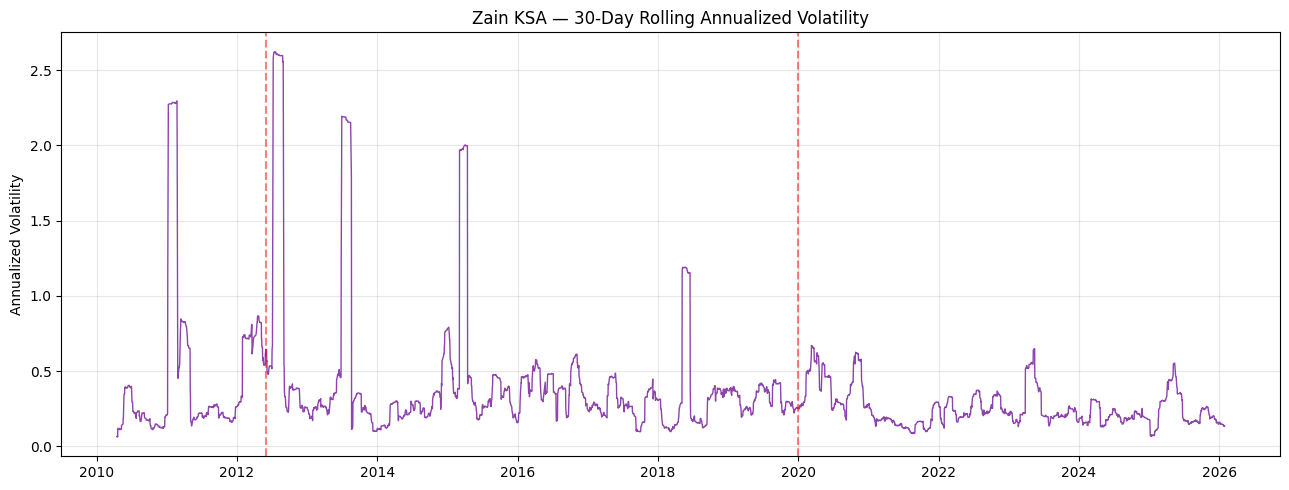

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["Date"], df["rolling_volatility_30d"], color="#8e44ad", linewidth=1)
for label, date in events.items():
    ax.axvline(pd.Timestamp(date), color="red", linestyle="--", alpha=0.5)
ax.set_title("Zain KSA — 30-Day Rolling Annualized Volatility")
ax.set_ylabel("Annualized Volatility")
plt.tight_layout()
plt.show()

## 6. Technical Indicators

Standard indicators an analyst would use to monitor this stock: RSI (momentum) and
Bollinger Bands (volatility bands around price).

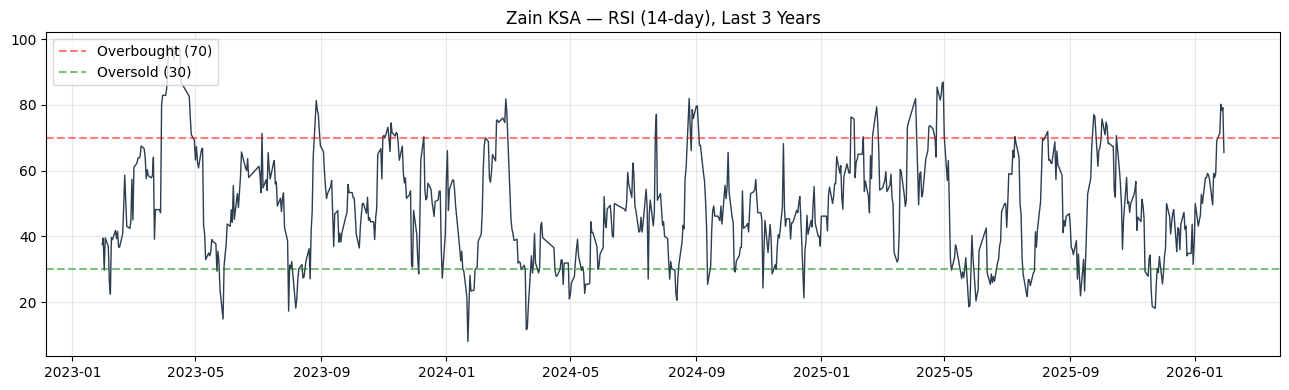

In [6]:
recent = df[df["Date"] >= df["Date"].max() - pd.Timedelta(days=3*365)]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(recent["Date"], recent["RSI_14"], color="#2c3e50", linewidth=1)
ax.axhline(70, color="red", linestyle="--", alpha=0.5, label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", alpha=0.5, label="Oversold (30)")
ax.set_title("Zain KSA — RSI (14-day), Last 3 Years")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

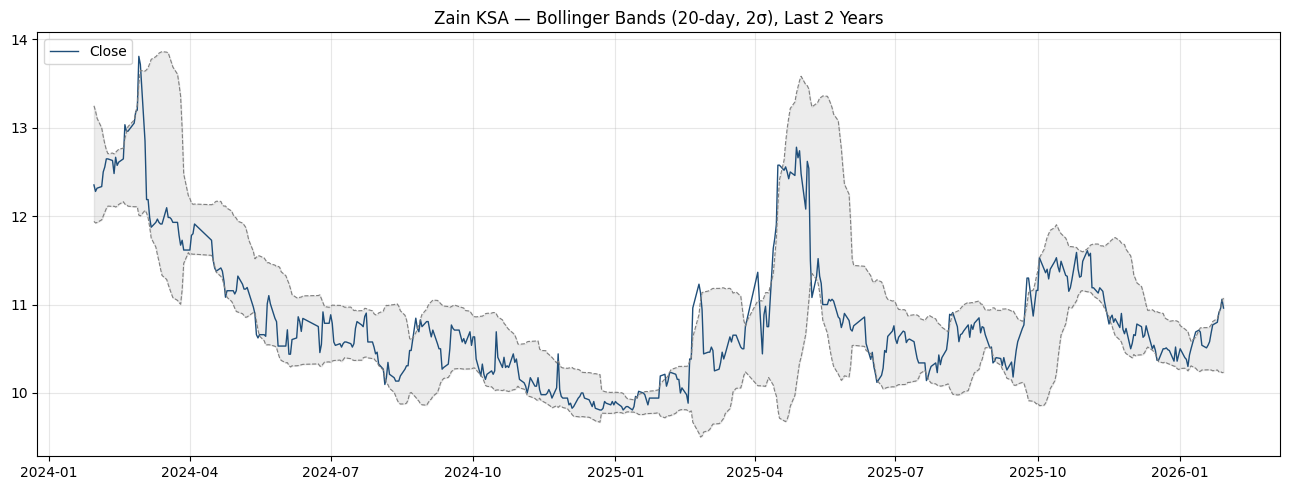

In [7]:
recent2 = df[df["Date"] >= df["Date"].max() - pd.Timedelta(days=2*365)]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(recent2["Date"], recent2["Close"], color="#1f4e79", linewidth=1, label="Close")
ax.plot(recent2["Date"], recent2["BB_upper"], color="gray", linewidth=0.8, linestyle="--")
ax.plot(recent2["Date"], recent2["BB_lower"], color="gray", linewidth=0.8, linestyle="--")
ax.fill_between(recent2["Date"], recent2["BB_lower"], recent2["BB_upper"], color="gray", alpha=0.15)
ax.set_title("Zain KSA — Bollinger Bands (20-day, 2σ), Last 2 Years")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 7. Yearly Returns

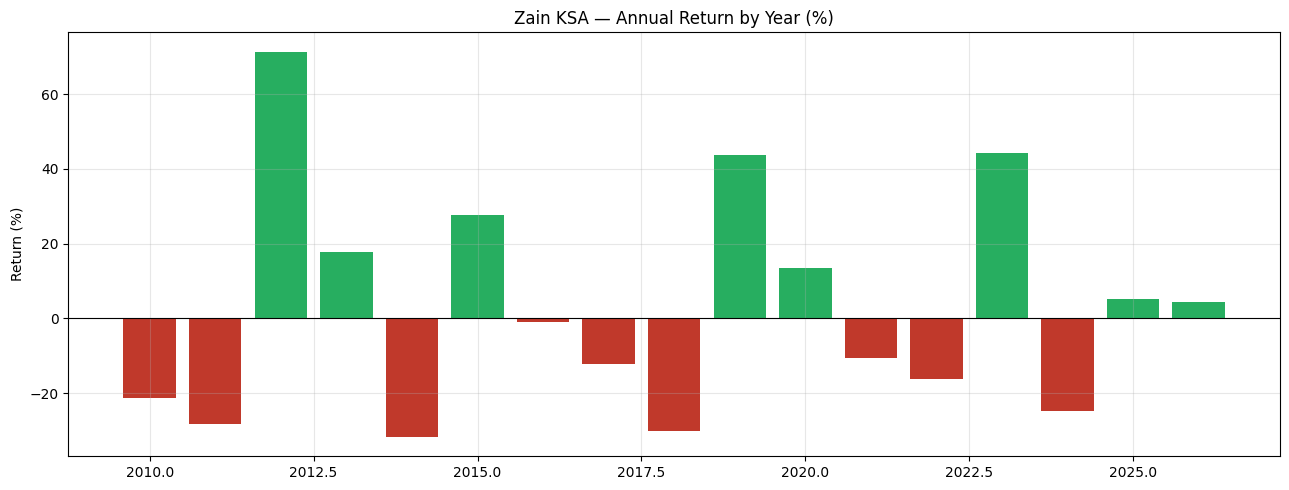

,year,start_price,end_price,avg_volume,annual_return_pct
0,2010,12.143493,9.554524,3.572101e+06,-21.319799
1,2011,9.554524,6.842272,6.142536e+06,-28.387097
2,2012,6.718988,11.518069,2.389328e+07,71.425658
3,2013,11.518069,13.559247,7.986824e+06,17.721527
4,2014,13.777945,9.403994,1.209043e+07,-31.746034
5,2015,9.549791,12.203321,5.307806e+06,27.786253
6,2016,12.203321,12.101263,2.740763e+06,-0.836309
7,2017,12.174162,10.687018,2.027212e+06,-12.215572
8,2018,10.701599,7.475665,2.817577e+06,-30.144416
9,2019,7.376231,10.612370,3.849327e+06,43.872540


In [8]:
yearly = pd.read_csv("data/yearly_returns.csv")
colors = ["#27ae60" if v >= 0 else "#c0392b" for v in yearly["annual_return_pct"]]
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(yearly["year"], yearly["annual_return_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Zain KSA — Annual Return by Year (%)")
ax.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()
yearly

## 8. Key Findings

1. **Corporate restructurings consistently trigger volatility spikes.** The 2012 capital
   reduction saw annualized volatility jump from ~66% to ~147% in the following 180 days;
   the 2020 restructuring saw a jump from ~31% to ~47%. Investors should expect elevated
   short-term risk around similar corporate actions.
2. **The stock has been range-bound rather than trending** over the 16-year window —
   the SMA 200 shows repeated cycles between roughly SAR 7–13 rather than sustained growth,
   consistent with a mature telecom operator in a competitive 3-player market.
3. **2012 and 2023 stand out as the strongest recovery years** (+71% and +44%
   respectively), both following prior down years — suggesting a pattern of sharp
   mean-reversion after selloffs.

## 9. Tools & Skills Demonstrated
Python (pandas, NumPy, matplotlib), time series analysis, technical indicator
construction (SMA, RSI, MACD, Bollinger Bands), event-impact analysis, data cleaning.
